In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [55]:
SEASON = "JJAS"
EXCL_RADIUS = 30

stats_dir = Path("/home/users/mendrika/Object-Based-LSTMConv/outputs/initiation/training/ci_core_assoc_stats")

# updated filename (causal + diurnal)
file = stats_dir / f"ci_core_stats_{SEASON}_diurnal_causal_excl{EXCL_RADIUS:03d}.csv"

df = pd.read_csv(file)

# inclusion radii of interest
radii = [25, 40]

# available lead times
leads = sorted(df["lead_time_min"].unique())

print("Loaded:", file)
print("Lead times:", leads)


Loaded: /home/users/mendrika/Object-Based-LSTMConv/outputs/initiation/training/ci_core_assoc_stats/ci_core_stats_JJAS_diurnal_causal_excl030.csv
Lead times: [np.int64(30), np.int64(60), np.int64(90), np.int64(120)]


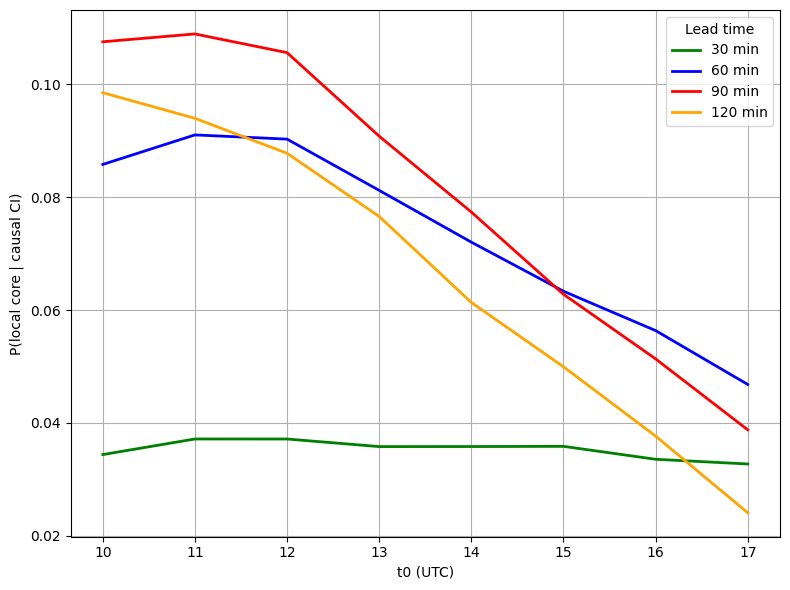

In [57]:
# fixed colours per lead time
color_map = {
    30: "green",
    60: "blue",
    90: "red",
    120: "orange"
}

fig, ax = plt.subplots(figsize=(8,6))

# only 25 km inclusion
RIN = 25

# plot curves
for lead in leads:
    df_plot = df[
        (df["incl_radius_km"] == RIN) &
        (df["lead_time_min"] == lead)
    ]
    
    ax.plot(
        df_plot["hour"],
        df_plot["p_incl_causal"],
        color=color_map[lead],
        linewidth=2
    )

# legend for lead time (top right)
lead_handles = [
    Line2D([0], [0], color=color_map[lead], lw=2, label=f"{lead} min")
    for lead in leads
]

ax.legend(
    handles=lead_handles,
    title="Lead time",
    loc="upper right",
    frameon=True
)

ax.set_xlabel("t0 (UTC)")
ax.set_ylabel("P(local core | causal CI)")
ax.grid(True)

plt.tight_layout()
plt.show()